Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно
***

# Введение: почему pandas? (1 pt)

Представьте: вам нужно проанализировать данные о пассажирах «Титаника» — 891 человек, 14 характеристик на каждого (пол, возраст, класс каюты, выживаемость и др.). 

В **табличном редакторе** (Excel):
- Ручной подсчёт среднего возраста выживших займёт минуты  
- Фильтрация «женщины первого класса» требует нескольких кликов  
- Анализ взаимосвязи «тариф - выживаемость» почти невозможен без макросов  

С помощью **Pandas**:
```python
df[df['survived'] == 1]['age'].mean()  # Средний возраст выживших — одна строка кода
```

А теперь представьте, если бы данных было больше!

Библиотека `pandas` нужна для работы именно с табличными данными. Однако табличные данные в жизни — это не единая сущность, а много разных форматов.   

**Форматы табличных файлов**

В реальной работе данные хранятся в разных форматах. Pandas умеет читать основные из них:

| Формат | Метод Pandas | Когда используется |
|--------|--------------|-------------------|
| **CSV** (Comma-Separated Values) | `pd.read_csv()` | Стандарт для обмена табличными данными (простой текст, легко читается) |
| **Excel** (.xlsx, .xls) | `pd.read_excel()` | Бизнес-отчёты, собранные данные |
| **JSON** | `pd.read_json()` | Данные от веб-API, вложенные структуры |
| **Встроенные датасеты** | `seaborn.load_dataset()` | Быстрый старт без скачивания файлов, но скорее для обучения |

> Подробнее можно почитать в [документации](https://pandas.pydata.org/docs/user_guide/io.html).

Для этого задания мы используем классический датасет **Titanic**, доступный «из коробки» через библиотеку Seaborn.

In [1]:
# Возможно вам надо установить библиотеки
%pip install ... 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\olegs\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip
ERROR: Directory '...' is not installable. Neither 'setup.py' nor 'pyproject.toml' found.


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np

Прежде, чем мы перейдем к работе с нашими данными давайте познакомимся с основой `pandas`.

Всё в Pandas строится вокруг двух ключевых типов данных:

| Структура | Описание | Аналогия | Пример |
|-----------|----------|----------|--------|
| **`pd.Series`** | Одномерный массив с **именованными индексами** | Столбец в Excel | `[20, 22, 19]` с индексами `['Анна', 'Борис', 'Вера']` |
| **`pd.DataFrame`** | Двумерная таблица из **нескольких Series** с общим индексом | Вся таблица Excel | Несколько столбцов (имя, возраст, ...) |

**Главное отличие**:  
- `Series` — один столбец данных + индекс  
- `DataFrame` — таблица из нескольких столбцов (`Series`), объединённых общим индексом

> Подробнее в документации: [pandas.Series](https://pandas.pydata.org/docs/reference/api/pandas.Series.html), [pandas.DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).

Многие функции возвращают эти типы данных или принимают их на вход. Конечно, мы будем работать с готовыми таблицами, но иногда важно уметь **создавать свои**.

In [3]:
# Создание Series из списка
grades = pd.Series([85, 92, 78, 95], index=['Анна', 'Борис', 'Вера', 'Глеб'])
print("Series:")
grades

Series:


Анна     85
Борис    92
Вера     78
Глеб     95
dtype: int64

In [4]:
# Создание DataFrame из словаря
data = {
    'имя': ['Анна', 'Борис', 'Вера', 'Глеб'],
    'возраст': [20, 22, 19, 21],
    'оценка': [5, 4, 3, 5]
}
df_example = pd.DataFrame(data, index=['студент_1', 'студент_2', 'студент_3', 'студент_4'])
print("DataFrame:")
df_example

DataFrame:


,имя,возраст,оценка
студент_1,Анна,20,5
студент_2,Борис,22,4
студент_3,Вера,19,3
студент_4,Глеб,21,5


> В примере названия столбцов и строк написаны на русском, но **ТАК ДЕЛАТЬ НЕ НАДО**. Лучше всего давать понятные названия на английском.

### Создание Series (0,5 pt)

In [5]:
# ЗАДАНИЕ: Создайте Series с названиями дней недели (понедельник–воскресенье) 
#          и количеством пар у вас в этот день в качестве значений.
#          Используйте английские названия дней как индекс (можно сократить).

days_series = pd.Series(
    data=[5,3,4,3,4,1,0], 
    index=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

days_series

Monday       5
Tuesday      3
Wednesday    4
Thursday     3
Friday       4
Saturday     1
Sunday       0
dtype: int64

Так можно получить отдельно индексы и отдельно значения

In [6]:
days_series.index

Index(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'],
      dtype='str')

In [7]:
days_series.values

array([5, 3, 4, 3, 4, 1, 0], dtype=int64)

> В [документации](https://pandas.pydata.org/docs/reference/api/pandas.Series.html) указаны все **атрибуты** (то, что вызывается через точку, но без скобок) и **методы** (то, что вызывается через точку и со скобками)

### Создание DataFrame (0,5 pt)

In [8]:
# ЗАДАНИЕ: Создайте DataFrame из словаря со следующими данными:
#          - Столбец 'город': ['Москва', 'Санкт-Петербург', 'Новосибирск']
#          - Столбец 'население': [12_500_000, 5_400_000, 1_600_000]
#          - Столбец 'регион': ['Центр', 'Северо-Запад', 'Сибирь']
#          Установите 'город' как индекс таблицы (параметр index=...)

cities_data = { 
    'город': ['Москва', 'Санкт-Петербург', 'Новосибирск'],
    'население': [12_500_000, 5_400_000, 1_600_000],
    'регион': ['Центр', 'Северо-Запад', 'Сибирь']
    }
cities_df = pd.DataFrame(cities_data).set_index('город')

# поменял с index=... на set_index(...) осознанно, чтобы лишний раз не прописывать: сразу добавил "город" в данные, а потом назначил этот столбец индексом

cities_df

,население,регион
город,,
Москва,12500000,Центр
Санкт-Петербург,5400000,Северо-Запад
Новосибирск,1600000,Сибирь


> В [документации](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) можно посмотреть и другие методы создания датафреймов.

# Работа с таблицами в Pandas

Теперь перейдем к работе с уже готовой таблицей. Для этого нам нужно загрузить данные.  
В этот раз мы будем использовать _встроенный датасет_, но потом нам придется использовать и другие методы считывания данных.

In [9]:
# Так же, как и pandas принято сокращать до pd,
# так и объекты типа DataFrame часто называют df (или data)

df = sns.load_dataset('titanic')

### Знакомство с данными (2 pt)

Перед анализом всегда нужно «осмотреть» данные. Базовый чек-лист:

| Метод | Что показывает | Пример использования |
|-------|----------------|----------------------|
| `.head(n)` | Первые `n` строк | `df.head(3)` — первые 3 строки |
| `.info()` | Типы данных, количество непустых значений | `df.info()` — найти пропуски и типы |
| `.describe()` | Статистика по числовым столбцам (среднее, мин/макс, квартили) | `df.describe()` — понять распределение |
| `.shape` | Размер датасета (строки, столбцы) | `df.shape[0]` — количество записей |
| `.columns` | Список названий столбцов | `df.columns.tolist()` |

Выведите первые 10 строк датасета и изучите их

In [10]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


Кстати, сколько всего записей в таблице? Какого таблица размера?

In [11]:
df.shape

(891, 15)

Изучите статистику таблицы и **напишите краткий вывод** о том, какие данные есть в таблице (каких типов, сколько, насколько данные «разбросаны» и так далее).

In [12]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Поскольку мне вообще не знаком датасет Титаника, я тут написал вопросы, которые у меня появились, хотя я подозреваю, что это датасет, созданный в учебных целях, и, видимо, так и задумано

Какие типы данных присутствуют:
- Булевые поля (alone, survived)
- Строковые поля (alive, embarked, embark_town) *Почему alive строковое, а не булевое?*
- Категориальные поля (deck, class)
- Вещественные поля (fare, age) *Почему age вещественное?*
- Целочисленные поля (sibsp, parch, survived, pclass) *Почему survived целочисленное?* 

Выводы, которые я сделал по `describe`:
- Всего 891 записей
- Средний возраст пассажира - 30 лет, есть люди от 0 до 80 лет, большей части людей около 40 лет
- В среднем у каждого второго есть близкий/родственник на борту (`mean(sibsp) = 0,52`)
- В среднем стоимость билета пассажира 32.2 доллара (`mean(fare) = 32.2`)
- Выжило 38% пассажиров
- Большинство пассажиров - третьего класса

Также для дальнейшего доступа и анализа нам важно знать, какие столбцы есть в таблице. Давайте отдельно посмотрим на **названия столбцов**.

In [13]:
column_names = df.columns
print(column_names)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


### Базовое «распределение» данных (1 pt)

Перед фильтрацией и агрегацией данных важно понять **распределение значений** в столбцах. Особенно для категориальных признаков (какие это столбцы?).

| Метод | Назначение | Пример для Titanic |
|-------|------------|-------------------|
| `.unique()` | Уникальные значения | `['мужчина', 'женщина']` |
| `.nunique()` | Количество уникальных значений | `2` (для столбца `sex`) |
| `.value_counts()` | Частота каждого значения | `мужчина: 577, женщина: 314` |

**Почему это важно?**  
Если вы не знаете, какие значения есть в столбце, вы не сможете правильно отфильтровать данные по этому столбцу!

> Как всегда подробнее в документации: [pandas.Series.unique](https://pandas.pydata.org/docs/reference/api/pandas.Series.unique.html), [pandas.Series.nunique](https://pandas.pydata.org/docs/reference/api/pandas.Series.nunique.html), [pandas.Series.value_counts](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html).
> При этом методы также имеют необязательные параметры. Например результат `.value_counts()` можно **сортировать** или **нормализовать**!

In [14]:
print(df['sex'].unique(), '\n')
print(df['class'].nunique(), '\n')
print(df['class'].value_counts())

<StringArray>
['male', 'female']
Length: 2, dtype: str 

3 

class
Third     491
First     216
Second    184
Name: count, dtype: int64


In [15]:
# ЗАДАНИЕ: Напишите код для ответа на следующие вопросы
#          1. Сколько уникальных значений в столбце 'who' и какие они?
#          2. Какое распределение пассажиров по столбцу 'alive' (выжившие/погибшие)?
#          3. Какие топ-2 порта посадки (столбец 'embarked') с помощью?

df_who_unique = df['who'].unique()
print(f"Уникальных значений в столбце 'who' - {len(df_who_unique)}: {df_who_unique.tolist()}")

alive_counts = df['alive'].value_counts()
print(f"{alive_counts['no']} погибших, {alive_counts['yes']} выживших")

top_ports = df['embarked'].value_counts(sort=True, dropna=False).head(2)
print(f"Топ-2 порта посадки: {top_ports.index[0]} ({top_ports.iloc[0]}), {top_ports.index[1]} ({top_ports.iloc[1]})")

Уникальных значений в столбце 'who' - 3: ['man', 'woman', 'child']
549 погибших, 342 выживших
Топ-2 порта посадки: S (644), C (168)


### Фильтрация данных (1 pt)

Часто нужно работать не со всем датасетом, а с подмножеством строк, удовлетворяющих условиям.

**Основные способы фильтрации**

| Способ | Синтаксис | Пример |
|--------|-----------|--------|
| **Логическая индексация** | `df[условие]` | `df[df['age'] > 30]` |
| **Метод `.loc[]`** | `df.loc[условие, столбцы]` | `df.loc[df['sex'] == 'female', ['age', 'fare']]` |
| **Комбинация условий** | `(условие1) & (условие2)` | `df[(df['sex'] == 'female') & (df['class'] == 'First')]` |

**Важно!** При комбинации условий **обязательны скобки** вокруг каждого условия:  
`df[df['age'] > 30 & df['fare'] < 50]` — ошибка  
`df[(df['age'] > 30) & (df['fare'] < 50)]` — правильно

> Подробнее о методах и различиях `loc` и `iloc` в документации: [pandas.DataFrame.loc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html), [Boolean indexing](https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing).

Обратите внимание, что привыйный доступ через целые индексы не всегда будет работать правильно. Особенно, если мы как-то отсортитуем датасет и индексы перемешаются (про то, как это править [тут](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html), когда-то вам это понадобится).

In [16]:
women = df[df['sex'] == 'female']
print(f"Количество женщин: {len(women)}")

Количество женщин: 314


In [17]:
# Вот тут из всех целых индексов остаются только 17, 21 и 23
survived_men = df.loc[(df['sex'] == 'male') & (df['survived'] == 1), ['age', 'fare']]
print("Первые 3 выживших мужчины (возраст и тариф):")
survived_men.head(3)

Первые 3 выживших мужчины (возраст и тариф):


,age,fare
17,NaN,13.0
21,34.0,13.0
23,28.0,35.5


In [18]:
# ЗАДАНИЕ:
#          1. Найдите всех выживших пассажиров женского пола. Сохраните результат в переменную women_survived.
#          2. Из полученного подмножества (женщины-выжившие) выберите только тех, кто путешествовал в первом классе.
#          3. Используя .loc[], выведите столбцы 'age' и 'fare' для пассажиров мужского пола младше 18 лет.

women_survived = df[(df['sex'] == 'female') & (df['alive'] == 'yes')]
women_first_class = women_survived[women_survived['class'] == 'First']
young_men = df.loc[(df['sex'] == 'male') & (df['age'] < 18)]

print(len(women_survived))
print(len(women_first_class))
print(young_men[['age', 'fare']].head())

233
91
     age     fare
7    2.0  21.0750
16   2.0  29.1250
50   7.0  39.6875
59  11.0  46.9000
63   4.0  27.9000


### Создание новых столбцов (1,5 pt)

Часто исходных данных недостаточно — нужно создавать производные признаки для анализа или выделять что-то из существующих

**Три основных метода**

| Способ | Синтаксис | Особенности | Когда использовать |
|--------|-----------|-------------|-------------------|
| **Прямое присваивание** | `df['новый_столбец'] = значения` | Изменяет исходный DataFrame «на месте» | Самый частый случай: создание производных признаков |
| **Метод `.assign()`** | `df.assign(новый_столбец=значения)` | Возвращает **новый** DataFrame, исходный не меняется | Цепочки операций |
| **`pd.concat()`** | `pd.concat([df, series], axis=1)` | Объединяет по столбцам (axis=1), требует согласования индексов | Добавление готового `Series` или внешнего столбца |

**Ключевое различие** в том, что  
- `df['col'] = ...` — **мутирует** исходный объект (изменяет его)  
- `.assign()` и `pd.concat()` — **возвращают новый** объект (исходный остаётся неизменным)

> Документация [pandas.DataFrame.assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html), [pandas.concat](https://pandas.pydata.org/docs/reference/api/pandas.concat.html).

***

**На основе чего можно создавать новые столбцы**

| Метод | Когда использовать | Пример |
|-------|-------------------|--------|
| **Прямое присваивание** | Простые арифметические операции | `df['family_size'] = df['sibsp'] + df['parch'] + 1` |
| **`np.where()`** | Бинарная классификация по условию | `df['is_child'] = np.where(df['age'] < 18, 'ребёнок', 'взрослый')` |
| **`pd.cut()`** | Разбиение на категории по диапазонам | `df['fare_cat'] = pd.cut(df['fare'], bins=[0, 50, 100, float('inf')], labels=['низкий', 'средний', 'высокий'])` |

В столбце `age` есть пропуски (NaN). При создании производных столбцов на основе `age` значения с пропусками автоматически станут `NaN` — это нормально, обработку пропусков мы изучим потом.

> Документация [pandas.cut](https://pandas.pydata.org/docs/reference/api/pandas.cut.html), [numpy.where](https://numpy.org/doc/stable/reference/generated/numpy.where.html)

In [19]:
df['age_group'] = np.where(
    df['age'] < 18, 
    'child',
    np.where(df['age'] >= 60, 'elderly', 'adult')
)
print(df['age_group'].value_counts(dropna=False))

age_group
adult      752
child      113
elderly     26
Name: count, dtype: int64


In [20]:
# ЗАДАНИЕ:
#          1. Создайте столбец 'in_a_large_group' (путешествует в большой группе): 
#             значение 1, если sibsp + parch >= 3, иначе 0.
#
#          2. Создайте столбец 'ticket_type':
#             - 'бюджетный' если fare <= 20
#             - 'стандартный' если 20 < fare <= 100
#             - 'премиум' если fare > 100
#
#          3. Создайте столбец 'age_category':
#             - bins = [0, 12, 18, 35, 60, float('inf')]
#             - labels = ['ребёнок', 'подросток', 'молодой', 'зрелый', 'пожилой']


# 1
df['in_a_large_group'] = df['sibsp'] + df['parch'] >= 3

# 2
df['ticket_type'] = (
    np.where(df['fare'] <= 20, 'бюджетный',
    np.where(df['fare'] > 100, 'премиум', 'стандарт')
))

# 3
df['age_category'] = pd.cut(df['age'], 
                            bins=[0, 12, 18, 35, 60, float('inf')], 
                            labels=['ребёнок', 'подросток', 'молодой', 'зрелый', 'пожилой'])


In [21]:
df['in_a_large_group'].value_counts(dropna=False)

in_a_large_group
False    800
True      91
Name: count, dtype: int64

In [22]:
df[['fare', 'ticket_type']].head()

,fare,ticket_type
0,7.2500,бюджетный
1,71.2833,стандарт
2,7.9250,бюджетный
3,53.1000,стандарт
4,8.0500,бюджетный


In [23]:
df['age_category'].value_counts(dropna=False)

age_category
молодой      358
зрелый       195
NaN          177
подросток     70
ребёнок       69
пожилой       22
Name: count, dtype: int64

### Агрегация данных (1,5 pt)

Теперь, когда вы уже можете многое делать с датасетом, можно считать различные статистики, выдвигать гипотезы и делать выводы.

Самая мощная операция в анализе — получение сводных показателей по группам.

**Как работает `.groupby()`**

In [24]:
# Шаг 1: Группировка по столбцу(ам)
# Шаг 2: Применение агрегирующей функции

# Пример: средний возраст по классам кают (попробуйте убрать параметр observed, можно ли это сделать?) 

# Можно, работает
df.groupby('class', observed=False)['age'].mean()
df.groupby('class', observed=True)['age'].mean()
df.groupby('class')['age'].mean()

class
First     38.233441
Second    29.877630
Third     25.140620
Name: age, dtype: float64

In [25]:
# Пример: несколько метрик сразу
df.groupby('sex').agg({
    'age': 'mean',
    'fare': 'median',
    'survived': 'sum'
})

,age,fare,survived
sex,,,
female,27.915709,23.0,233
male,30.726645,10.5,109


В целом все статистики можно считать и просто по столбцам, но `groupby` помогает делать более сложное более быстрым.

| Агрегирующая функция | Что считает | Пример |
|-------|-------------------|--------|
| `.mean()` | Среднее арифметическое | Средний возраст |
| `.median()` | Медиана | Медианный тариф |
| `.sum()` | Сумма | Общее число выживших|
| `.count()` | Количество непустых значений | Число пассажиров в группе |
| `.agg({...})` | Несколько функций сразу | Среднее + сумма в одной таблице |

**Важно**: `.groupby()` не изменяет исходный датасет — он возвращает новый объект, который нужно либо вывести, либо сохранить в переменную.

> Подробнее про [groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) и [гайд](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html).

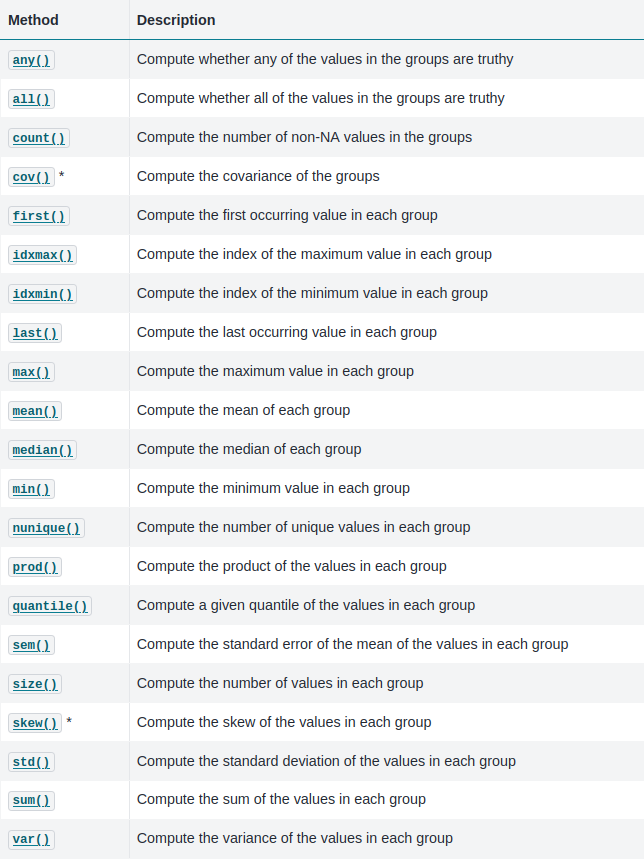

In [26]:
# ЗАДАНИЕ: 
#         1. Рассчитайте средний тариф (fare) для каждого класса каюты (class). 
#            Отсортируйте результат по убыванию среднего тарифа.
#
#         2. Для каждой комбинации (пол, класс каюты) рассчитайте:
#            - количество пассажиров
#            - средний возраст
#            - процент выживших (количество выживших / общее количество * 100)

avg_fare_by_class = df.groupby('class')['fare'].mean().sort_values(ascending=False)

sex_class_stats = df.groupby(['sex', 'class']).agg(
    passenger_count=('survived', 'count'),          
    mean_age=('age', 'mean'),                       
    survived_percent=('survived', lambda x: round(x.mean() * 100, 2))  
)
# Переименуйте столбцы согласно их смыслу
#sex_class_stats.columns = ['...', '...', '...']

# Я узнал, что можно их переименовывать сразу, поэтому сделал так, как написано выше

In [27]:
# print выводит некрасиво, приятнее использовать преимущества ipynb
avg_fare_by_class

class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64

In [28]:
sex_class_stats

passenger_count   mean_age  survived_percent
sex    class                                               
female First                94  34.611765             96.81
       Second               76  28.722973             92.11
       Third               144  21.750000             50.00
male   First               122  41.281386             36.89
       Second              108  30.740707             15.74
       Third               347  26.507589             13.54

### Подведение итогов (2 pt)

_Теперь вы умеете_
* делать базовый анализ датасета,  
* смотреть распределения данных,  
* фильтровать данные,
* создавать новые фичи,
* агрегировать и считать статистики.

_Пора все знания зафиналить и собрать все вместе._

***

**ЗАДАНИЕ:**  
Для каждой возрастной категории (столбец `age_category`, созданного в одном из заданий) определите:
1. Количество пассажиров
2. Средний тариф
3. Процент выживших
4. Самый популярный порт посадки (режим — наиболее частое значение)

Отсортируйте результат по убыванию процента выживших.

Сделайте **вывод** из тех данных, которве у вас получились

In [29]:
age_stats = df.groupby('age_category').agg(
    passenger_count=('survived', 'count'),
    mean_fare=('fare', 'mean'),
    survived_percent=('survived', lambda x: round(x.mean() * 100, 2)),
    most_common_port=('embarked', lambda x: x.value_counts().index[0])
)

age_stats.sort_values(by='survived_percent', ascending=False)

,passenger_count,mean_fare,survived_percent,most_common_port
age_category,,,,
ребёнок,69,31.536352,57.97,S
подросток,70,33.451313,42.86,S
зрелый,195,44.259658,40.00,S
молодой,358,29.925929,38.27,S
пожилой,22,41.371214,22.73,S


Краткие выводы по полученным данным:
- Чем моложе пассажир, тем больше шанс выживания оказался (в среднем)
- У зрелых и пожилых средняя стоимость билета значительно выше, чем у других возрастных категорий
- Самый популярный порт посадки (у всех возрастных категорий) был S (Southampton, судя по всему)
- Больше всего молодых пассажиров на борту, меньше всего - пожилых